<a href="https://colab.research.google.com/github/Albonire/clasificador-imagenes-openmp-cuda/blob/main/etapa2_cuda/cpu_baseline/base-model-cpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline CPU — Clasificador de Somnolencia (MLP)
**Programacion Paralela y Computacion Distribuida · Universidad de Pamplona · 2026-I**

Este notebook entrena, **solo en CPU**, la misma red que luego se implementara con
kernels propios de CUDA en `etapa2_cuda`. Sirve como linea base de tiempo y exactitud
para calcular el *speedup* de la version GPU (mismo modelo, mismos datos, mismas epocas).

**Arquitectura (binaria, MLP de una sola capa oculta):**

```
Entrada(4096) -> Densa(oculta, ReLU) -> Densa(1, Sigmoide)
```

- **Perdida:** Binary Cross-Entropy (BCE)
- **Optimizador:** SGD (`peso = peso - tasa_aprendizaje * gradiente`)
- **Modo de entrenamiento:** full-batch (todo el train set por epoca), para que el
  tiempo de CPU sea comparable 1:1 con el kernel CUDA (que tambien procesara el
  dataset completo por epoca en lugar de mini-batches aleatorios).

**Contenido:**
1. Configuracion (entorno, semilla, forzar CPU)
2. Carga del dataset (`dataset/procesado/{train,val,test}.csv`)
3. Arquitectura del modelo (TensorFlow/Keras)
4. Busqueda de hiperparametros (epocas 20-50, lr 0.01-0.1, ocultas 64-128)
5. Entrenamiento final en CPU (tiempo medido)
6. Evaluacion en test
7. Exportacion de pesos (`W1, b1, W2, b2`, mismo formato que `app_streamlit`)
8. Reporte (`cpu_baseline_report.md`)


---
## 1. Configuración

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Albonire/clasificador-imagenes-openmp-cuda.git"
REPO_DIR = "/content/clasificador-imagenes-openmp-cuda"

if IN_COLAB and not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}

if IN_COLAB:
    os.chdir(os.path.join(REPO_DIR, "etapa2_cuda", "cpu_baseline"))

print(f"En Colab: {IN_COLAB}")
print(f"Directorio de trabajo: {os.getcwd()}")

Cloning into '/content/clasificador-imagenes-openmp-cuda'...
remote: Enumerating objects: 1385, done.
remote: Counting objects: 100% (1385/1385), done.
remote: Compressing objects: 100% (1378/1378), done.
remote: Total 1385 (delta 3), reused 1377 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (1385/1385), 127.03 MiB | 26.52 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (1374/1374), done.
En Colab: True
Directorio de trabajo: /content/clasificador-imagenes-openmp-cuda/etapa2_cuda/cpu_baseline


In [2]:
!pip install tensorflow matplotlib scikit-learn

In [3]:
import tensorflow as tf

import datetime
import itertools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Linea base de CPU: deshabilitar la GPU aunque el runtime la tenga disponible,
# para que el tiempo medido aqui sea estrictamente CPU-only.
tf.config.set_visible_devices([], "GPU")

print(f"TensorFlow version: {tf.__version__}")
print("Dispositivos visibles:")
for device in tf.config.get_visible_devices():
    print(f"  {device}")

TensorFlow version: 2.20.0
Dispositivos visibles:
  PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


In [4]:
# --- Rutas del repositorio ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.exists(os.path.join(REPO_ROOT, "dataset")):
    REPO_ROOT = os.getcwd()

PATHS = {
    "procesado": os.path.join(REPO_ROOT, "dataset", "procesado"),
    "evidencias": os.path.join(REPO_ROOT, "reporte", "evidencias"),
    "baseline": os.path.join(REPO_ROOT, "etapa2_cuda", "cpu_baseline"),
}

for name, path in PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"  {'OK' if os.path.isdir(path) else 'WARN'} {name}: {path}")

TRAIN_CSV = os.path.join(PATHS["procesado"], "train.csv")
VAL_CSV = os.path.join(PATHS["procesado"], "val.csv")
TEST_CSV = os.path.join(PATHS["procesado"], "test.csv")

print(f"\nTrain CSV: {TRAIN_CSV}")
print(f"Val CSV:   {VAL_CSV}")
print(f"Test CSV:  {TEST_CSV}")

  OK procesado: /content/clasificador-imagenes-openmp-cuda/dataset/procesado
  OK evidencias: /content/clasificador-imagenes-openmp-cuda/reporte/evidencias
  OK baseline: /content/clasificador-imagenes-openmp-cuda/etapa2_cuda/cpu_baseline

Train CSV: /content/clasificador-imagenes-openmp-cuda/dataset/procesado/train.csv
Val CSV:   /content/clasificador-imagenes-openmp-cuda/dataset/procesado/val.csv
Test CSV:  /content/clasificador-imagenes-openmp-cuda/dataset/procesado/test.csv


---
## 2. Carga del dataset

Particiones generadas en `notebooks/dataset_preparation.ipynb` (70/15/15,
estratificadas, sin overlap). Formato canonico: `label, pixel_0 .. pixel_4095`.

In [5]:
TARGET = "label"


def load_split(path):
    df = pd.read_csv(path)
    feature_cols = [c for c in df.columns if c != TARGET]
    x = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[TARGET].to_numpy(dtype=np.float32)
    return x, y


X_train, y_train = load_split(TRAIN_CSV)
X_val, y_val = load_split(VAL_CSV)
X_test, y_test = load_split(TEST_CSV)

N_FEATURES = X_train.shape[1]
assert N_FEATURES == 4096, f"Se esperaban 4096 features (64x64), se obtuvieron {N_FEATURES}"

for name, x, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"{name}: {x.shape}, positivos(clase1)={int(y.sum())} ({y.mean() * 100:.1f}%)")

print(f"\nFeatures: {N_FEATURES}")
print(f"Rango de pixeles: [{X_train.min():.4f}, {X_train.max():.4f}]")

Train: (935, 4096), positivos(clase1)=485 (51.9%)
Val: (201, 4096), positivos(clase1)=105 (52.2%)
Test: (201, 4096), positivos(clase1)=104 (51.7%)

Features: 4096
Rango de pixeles: [0.0000, 1.0000]


---
## 3. Arquitectura del modelo (MLP)

Una sola capa oculta: suficiente para clasificacion binaria y evita programar la
convolucion hacia atras en CUDA (esa parte ya se hizo en OpenMP, etapa 1).

`Entrada(4096) -> Densa(oculta, ReLU) -> Densa(1, Sigmoide)`

Los kernels que reemplazaran cada pieza en CUDA:
- Densa(forward) → multiplicacion matriz-vector / matriz-matriz
- ReLU → suma de bias + ReLU
- Sigmoide → kernel de activacion de salida
- `binary_crossentropy` → kernel de perdida BCE
- `model.fit` (backprop) → kernels de gradiente (capa oculta y salida)
- `optimizers.SGD` → kernel de actualizacion de pesos (`peso -= lr * grad`)

In [6]:
def build_model(hidden_units, learning_rate):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(N_FEATURES,)),
        tf.keras.layers.Dense(hidden_units, activation="relu", name="hidden"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


build_model(64, 0.1).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,273 (1.00 MB)

 Trainable params: 262,273 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Busqueda de hiperparametros

Rango sugerido por la guia: epocas 20-50, tasa de aprendizaje 0.01-0.1,
neuronas ocultas 64-128. Se prueban los extremos de cada rango (grilla 2x2x2)
y se elige la combinacion con mejor `accuracy` en validacion.

In [7]:
HIDDEN_GRID = [64, 128]
LR_GRID = [0.01, 0.1]
EPOCHS_GRID = [20, 50]

results = []

for hidden_units, learning_rate, epochs in itertools.product(HIDDEN_GRID, LR_GRID, EPOCHS_GRID):
    tf.random.set_seed(SEED)
    model = build_model(hidden_units, learning_rate)

    start = time.perf_counter()
    model.fit(
        X_train, y_train,
        batch_size=X_train.shape[0],  # full-batch, igual al kernel CUDA
        epochs=epochs,
        validation_data=(X_val, y_val),
        verbose=0,
    )
    elapsed = time.perf_counter() - start

    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    results.append({
        "hidden_units": hidden_units,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "train_time_sec": elapsed,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
    })
    print(
        f"hidden={hidden_units:3d} lr={learning_rate:<5} epochs={epochs:3d} "
        f"-> val_acc={val_accuracy:.4f} val_loss={val_loss:.4f} time={elapsed:.2f}s"
    )

results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
results_df

hidden= 64 lr=0.01  epochs= 20 -> val_acc=0.7313 val_loss=0.6808 time=12.54s
hidden= 64 lr=0.01  epochs= 50 -> val_acc=0.7960 val_loss=0.6763 time=10.57s
hidden= 64 lr=0.1   epochs= 20 -> val_acc=0.8408 val_loss=0.6082 time=3.26s
hidden= 64 lr=0.1   epochs= 50 -> val_acc=0.8607 val_loss=0.5275 time=6.50s
hidden=128 lr=0.01  epochs= 20 -> val_acc=0.5871 val_loss=0.6815 time=2.93s
hidden=128 lr=0.01  epochs= 50 -> val_acc=0.8209 val_loss=0.6627 time=7.34s
hidden=128 lr=0.1   epochs= 20 -> val_acc=0.8657 val_loss=0.6109 time=2.87s
hidden=128 lr=0.1   epochs= 50 -> val_acc=0.8507 val_loss=0.5229 time=7.60s


,hidden_units,learning_rate,epochs,train_time_sec,val_loss,val_accuracy
0,128,0.10,20,2.870529,0.610914,0.865672
1,64,0.10,50,6.502798,0.527486,0.860696
2,128,0.10,50,7.601629,0.522919,0.850746
3,64,0.10,20,3.257590,0.608200,0.840796
4,128,0.01,50,7.341877,0.662706,0.820895
5,64,0.01,50,10.565896,0.676286,0.796020
6,64,0.01,20,12.537831,0.680757,0.731343
7,128,0.01,20,2.928860,0.681529,0.587065


In [8]:
best = results_df.iloc[0]
BEST_HIDDEN = int(best["hidden_units"])
BEST_LR = float(best["learning_rate"])
BEST_EPOCHS = int(best["epochs"])

print("Mejor combinacion (mayor accuracy en validacion):")
print(f"  hidden_units  = {BEST_HIDDEN}")
print(f"  learning_rate = {BEST_LR}")
print(f"  epochs        = {BEST_EPOCHS}")
print(f"  val_accuracy  = {best['val_accuracy']:.4f}")
print(f"  val_loss      = {best['val_loss']:.4f}")

Mejor combinacion (mayor accuracy en validacion):
  hidden_units  = 128
  learning_rate = 0.1
  epochs        = 20
  val_accuracy  = 0.8657
  val_loss      = 0.6109


---
## 5. Entrenamiento final en CPU

Se reentrena desde cero con la mejor combinacion y se mide el tiempo total con
`time.perf_counter()`. Este numero (`CPU_TRAIN_TIME_SEC`) es la linea base para el
speedup de la version CUDA.

In [9]:
tf.random.set_seed(SEED)
final_model = build_model(BEST_HIDDEN, BEST_LR)

print(f"Entrenamiento final: hidden={BEST_HIDDEN}, lr={BEST_LR}, epochs={BEST_EPOCHS}")

start = time.perf_counter()
final_history = final_model.fit(
    X_train, y_train,
    batch_size=X_train.shape[0],
    epochs=BEST_EPOCHS,
    validation_data=(X_val, y_val),
    verbose=0,
)
CPU_TRAIN_TIME_SEC = time.perf_counter() - start

print(f"\nTiempo de entrenamiento en CPU: {CPU_TRAIN_TIME_SEC:.4f} s ({BEST_EPOCHS} epocas)")
print(f"Muestras de entrenamiento: {X_train.shape[0]}")

Entrenamiento final: hidden=128, lr=0.1, epochs=20

Tiempo de entrenamiento en CPU: 3.1745 s (20 epocas)
Muestras de entrenamiento: 935


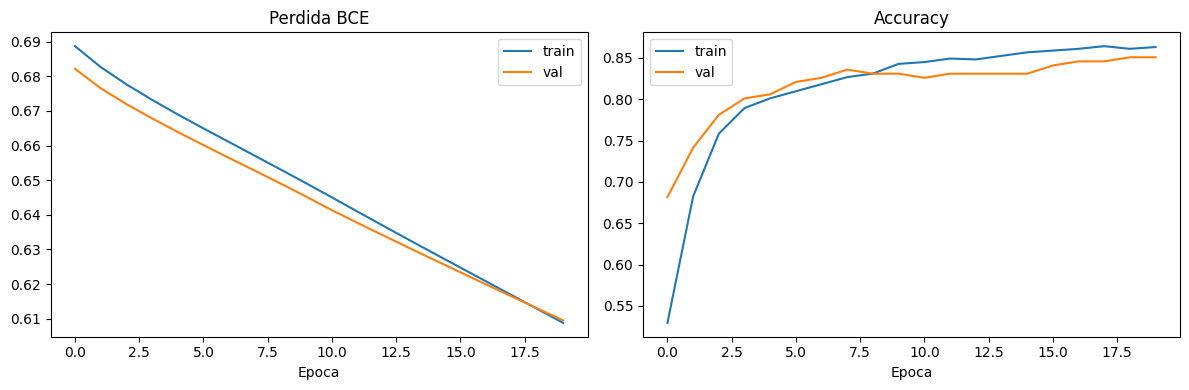

  /content/clasificador-imagenes-openmp-cuda/reporte/evidencias/cpu_baseline_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(final_history.history["loss"], label="train")
axes[0].plot(final_history.history["val_loss"], label="val")
axes[0].set_title("Perdida BCE")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(final_history.history["accuracy"], label="train")
axes[1].plot(final_history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()

plt.tight_layout()
curves_path = os.path.join(PATHS["evidencias"], "cpu_baseline_training_curves.png")
fig.savefig(curves_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"  {curves_path}")

---
## 6. Evaluacion en test

In [12]:
y_prob = final_model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(np.int32)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Test accuracy:  {acc:.4f}")
print(f"Test precision: {prec:.4f}")
print(f"Test recall:    {rec:.4f}")
print(f"Test F1:        {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Abiertos (0)", "Cerrados (1)"]))

Test accuracy:  0.8159
Test precision: 0.8252
Test recall:    0.8173
Test F1:        0.8213

              precision    recall  f1-score   support

Abiertos (0)       0.81      0.81      0.81        97
Cerrados (1)       0.83      0.82      0.82       104

    accuracy                           0.82       201
   macro avg       0.82      0.82      0.82       201
weighted avg       0.82      0.82      0.82       201



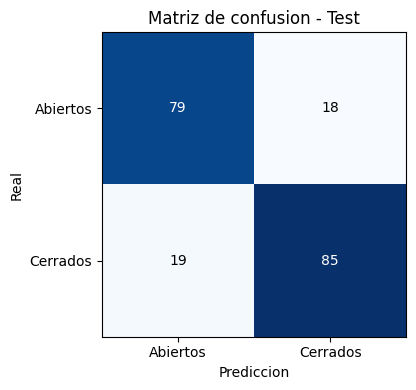

  /content/clasificador-imagenes-openmp-cuda/reporte/evidencias/cpu_baseline_confusion_matrix.png


In [13]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Abiertos", "Cerrados"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Abiertos", "Cerrados"])
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusion - Test")
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(cm[i, j]), ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.tight_layout()
cm_path = os.path.join(PATHS["evidencias"], "cpu_baseline_confusion_matrix.png")
fig.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"  {cm_path}")

---
## 7. Exportacion de pesos

Mismo formato que espera `app_streamlit/app.py` (`W1, b1, W2, b2`, con
`W1: (oculta, entrada)` y `W2: (1, oculta)` para poder hacer `W @ x + b`).
Se guarda como checkpoint de esta linea base, sin sobrescribir
`modelo/weights.npz` (reservado para el modelo final entrenado en CUDA).

In [14]:
w1_keras, b1_keras = final_model.get_layer("hidden").get_weights()
w2_keras, b2_keras = final_model.get_layer("output").get_weights()

W1 = w1_keras.T  # (oculta, entrada)
b1 = b1_keras  # (oculta,)
W2 = w2_keras.T  # (1, oculta)
b2 = b2_keras  # (1,)

weights_path = os.path.join(PATHS["baseline"], "weights_cpu_baseline.npz")
np.savez(weights_path, W1=W1, b1=b1, W2=W2, b2=b2)

print(f"Pesos guardados: {weights_path}")
print(f"  W1: {W1.shape}, b1: {b1.shape}, W2: {W2.shape}, b2: {b2.shape}")

Pesos guardados: /content/clasificador-imagenes-openmp-cuda/etapa2_cuda/cpu_baseline/weights_cpu_baseline.npz
  W1: (128, 4096), b1: (128,), W2: (1, 128), b2: (1,)


---
## 8. Reporte

Resumen de la grilla de hiperparametros, la mejor combinacion, el tiempo de
entrenamiento en CPU y las metricas en test.

In [15]:
report_path = os.path.join(PATHS["baseline"], "cpu_baseline_report.md")
now = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("# CPU Baseline Report — Clasificador de Somnolencia\n\n")
    f.write(f"**Generado:** {now}\n\n")

    f.write("## Arquitectura\n\n")
    f.write(f"`Entrada({N_FEATURES}) -> Densa({BEST_HIDDEN}, ReLU) -> Densa(1, Sigmoide)`\n\n")
    f.write("- **Perdida:** Binary Cross-Entropy\n")
    f.write("- **Optimizador:** SGD (sin momentum)\n")
    f.write("- **Modo de entrenamiento:** full-batch (todo el train set por epoca)\n\n")

    f.write("## Busqueda de hiperparametros\n\n")
    f.write("| hidden_units | learning_rate | epochs | train_time_sec | val_loss | val_accuracy |\n")
    f.write("|---|---|---|---|---|---|\n")
    for _, row in results_df.iterrows():
        f.write(
            f"| {int(row['hidden_units'])} | {row['learning_rate']} | {int(row['epochs'])} | "
            f"{row['train_time_sec']:.4f} | {row['val_loss']:.4f} | {row['val_accuracy']:.4f} |\n"
        )
    f.write(f"\n**Mejor combinacion:** hidden={BEST_HIDDEN}, lr={BEST_LR}, epochs={BEST_EPOCHS}\n\n")

    f.write("## Entrenamiento final (CPU)\n\n")
    f.write(f"- **Tiempo de entrenamiento:** {CPU_TRAIN_TIME_SEC:.4f} s\n")
    f.write(f"- **Muestras de entrenamiento:** {X_train.shape[0]}\n")
    f.write(f"- **Epocas:** {BEST_EPOCHS}\n\n")

    f.write("## Metricas en test\n\n")
    f.write("| Metrica | Valor |\n|---------|-------|\n")
    f.write(f"| Accuracy | {acc:.4f} |\n")
    f.write(f"| Precision | {prec:.4f} |\n")
    f.write(f"| Recall | {rec:.4f} |\n")
    f.write(f"| F1 | {f1:.4f} |\n\n")

    f.write("## Uso\n\n")
    f.write(
        "`CPU_TRAIN_TIME_SEC` es la linea base para calcular el speedup de la "
        "implementacion CUDA en `etapa2_cuda` (mismo modelo, mismos datos, mismas epocas).\n"
    )

print(f"Reporte guardado: {report_path}")

Reporte guardado: /content/clasificador-imagenes-openmp-cuda/etapa2_cuda/cpu_baseline/cpu_baseline_report.md


---
## Siguiente paso

La implementacion en CUDA (`etapa2_cuda`) debe usar **la misma arquitectura y los
mismos hiperparametros** elegidos aqui (`hidden_units`, `learning_rate`, `epochs`)
y entrenar sobre los mismos `train.csv` / `val.csv` / `test.csv`, para que el
speedup GPU vs. CPU sea una comparacion valida. Pendiente medir ademas:

- `nvidia-smi` durante el entrenamiento en GPU (% utilizacion, memoria)
- Efecto del tamano de bloque (16×16, 32×32, ...) en los kernels CUDA